In [7]:
import numpy as np
import matplotlib.pyplot as plt
import ot

### Solve the Optimal Transport problem between the samples

The `ot.utils.OTResult` object contains the following attributes:
- `value`: the value of the OT problem
- `plan`: the OT matrix
- `potentials`: Dual potentials of the OT problem
- `log`: log dictionary of the solver

The OT matrix $P$ is a matrix of size `(n1, n2)` where `P[i,j]` is the amount of mass transported from `x1[i]` to `x2[j]`. 

In [14]:
# Problem size
n1 = 25
n2 = 50

# Generate random data
np.random.seed(0)
a = ot.utils.unif(n1)  # Weights of points in the source domain
b = ot.utils.unif(n2)  # Weights of points in the target domain

x1 = np.random.randn(n1, 2)  # Source points
x1 /= np.sqrt(np.sum(x1 ** 2, axis=1, keepdims=True)) / 2       # Normalize to lie on the unit circle

x2 = np.random.randn(n2, 2)  # Target points
x2 /= np.sqrt(np.sum(x2 ** 2, axis=1, keepdims=True)) / 4       # Normalize to lie on the unit circle

In [15]:
# Solve the OT problem
sol = ot.solve_sample(x1, x2, a, b)

# get the OT plan
P = sol.plan

# get the OT loss
loss = sol.value

# get the dual potentials
alpha, beta = sol.potentials

print(f"OT loss = {loss:1.3f}")
print(f"OT plan = {P}")
print(f"Dual potentials = {alpha}, {beta}")

OT loss = 5.292
OT plan = [[0.   0.   0.   ... 0.   0.   0.  ]
 [0.   0.   0.   ... 0.   0.   0.  ]
 [0.   0.   0.   ... 0.   0.   0.  ]
 ...
 [0.   0.   0.   ... 0.   0.   0.02]
 [0.   0.   0.   ... 0.   0.   0.  ]
 [0.   0.   0.   ... 0.   0.   0.  ]]
Dual potentials = [ 7.18032826  0.63426062 10.14324932  9.3316479  -3.8796408  -1.99712655
  7.53822821  4.08804663  9.22257994  7.07534884 -4.4967778   9.14090657
 10.00983884  7.07314739  3.07082327  0.46949043  3.5174877  -4.69239444
  2.98614876  0.49661808  2.00948899 -5.38685179  0.84205698 -5.03745102
 -3.19095089], [ 8.69407785  0.17105233  5.15533368  3.63399722  3.35050009  3.54012738
  0.48535735 -3.57915365  8.50217162  7.4736265  -4.4522919  -5.48955307
 -4.27674108  2.95010124  7.95079519  9.12178166 -3.04933986  0.40078094
 -5.3313085   9.43114926  7.37017001  3.69004214  1.56835333  4.66585526
  2.893332   -5.98876555  9.11165308  8.57902615  0.53902619 -1.70327065
 -2.85560583  8.13049115  7.39461268 -5.33150522  0.8210

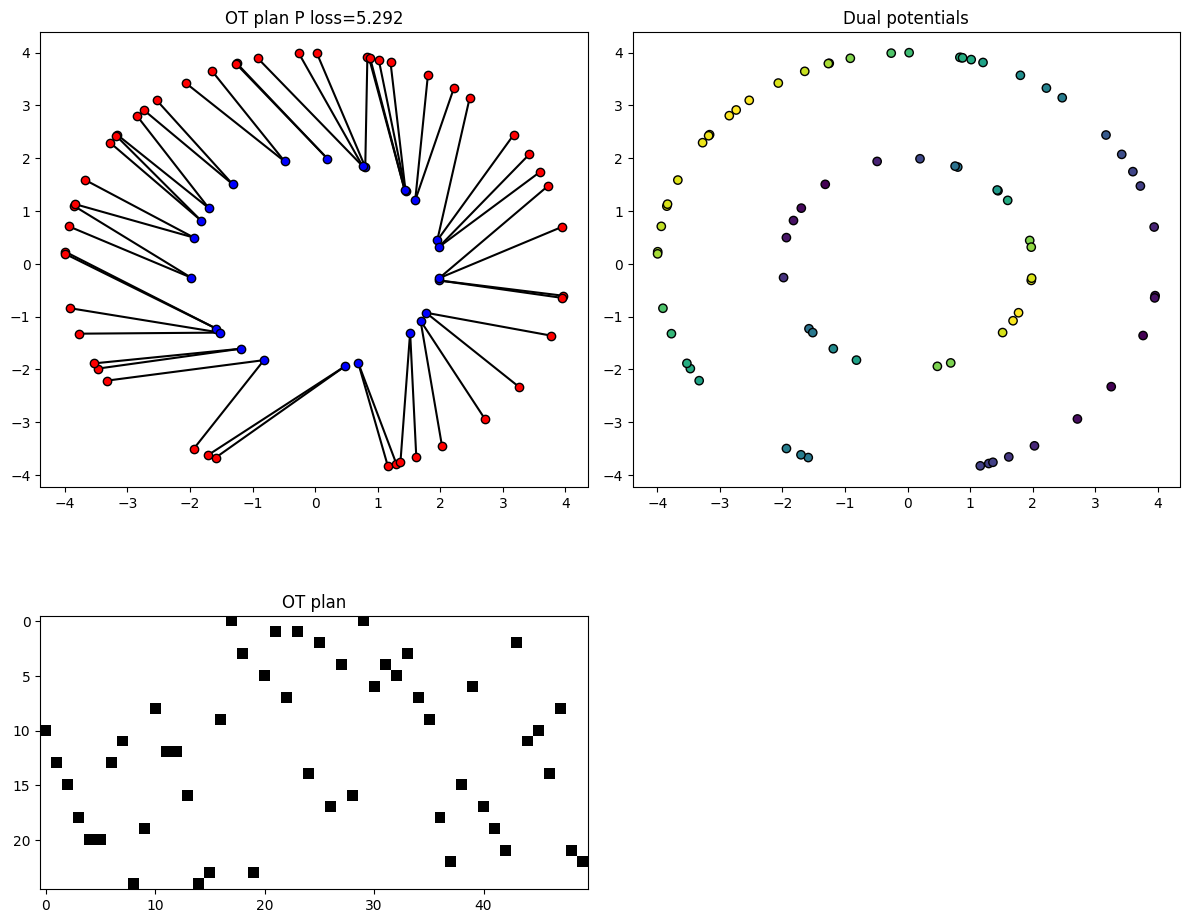

In [16]:
plt.figure(figsize=(12, 10))

# Plot OT plan
plt.subplot(2, 2, 1)
for i in range(n1):
    for j in range(n2):
        if P[i, j] > 1e-8:
            plt.plot([x1[i, 0], x2[j, 0]], [x1[i, 1], x2[j, 1]], color='black', zorder=0)
plt.scatter(x1[:, 0], x1[:, 1], c='blue', edgecolors='k', zorder=1)
plt.scatter(x2[:, 0], x2[:, 1], c='red', edgecolors='k', zorder=1)
plt.title(f'OT plan P loss={loss:1.3f}')

# Plot dual potentials
plt.subplot(2, 2, 2)
plt.scatter(x1[:, 0], x1[:, 1], c=alpha, edgecolors='k')
plt.scatter(x2[:, 0], x2[:, 1], c=beta, edgecolors='k')
plt.title('Dual potentials')

# Plot OT plan matrix
plt.subplot(2, 2, 3)
plt.imshow(P, cmap='Greys', interpolation='Nearest')
plt.title('OT plan')

plt.tight_layout()
plt.show()

### Optimal Transport problem with a custom cost matrix

The cost matrix can be customized by passing it to the more general `ot.solve()` function. The cost matrix should be a matrix of size `(n1, n2)` where `C[i,j]` is the cost of transporting mass from `x1[i]` to `x2[j]`.

In [18]:
# Compute the cost matrix
C_city = ot.dist(x1, x2, metric="cityblock")

print(C_city)

# Solve the OT problem with the custom cost matrix
sol = ot.solve(C_city)
# the parameters a and b are not provided so uniform weights are assumed
P_city = sol.plan
# on empirical data the same can be done with ot.solve_sample :
sol = ot.solve_sample(x1, x2, metric='cityblock')

# Compute the OT loss (equivalent to ot.solve(C).value)
loss_city = sol.value  # same as np.sum(P_city * C)

[[6.76644163 7.65234865 5.76199227 ... 2.79947097 7.13645601 7.49141036]
 [4.71871165 7.89277504 3.22167555 ... 3.27717231 4.59613929 7.73183675]
 [7.95776681 6.10420734 6.95331745 ... 4.34761229 8.32778119 5.94326905]
 ...
 [5.04541996 2.43906687 6.54915111 ... 8.01275276 5.41543433 2.27812858]
 [2.50446636 4.83676868 4.37348058 ... 5.83708222 2.87448073 4.45379911]
 [3.53695979 3.80427525 5.97297819 ... 7.43657984 3.90697416 2.8543015 ]]


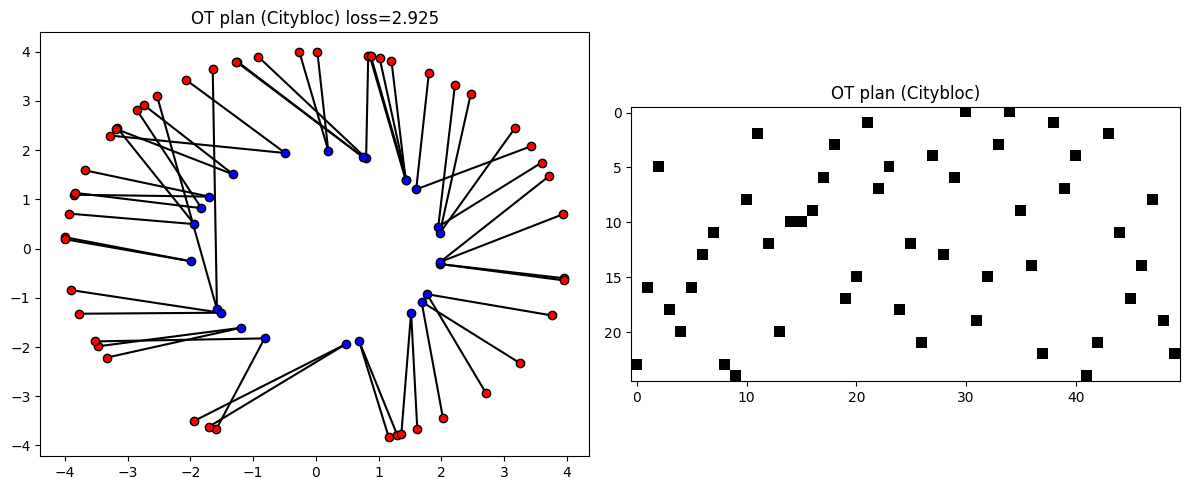

In [19]:
plt.figure(figsize=(12, 5))

# Plot OT plan (Cityblock)
plt.subplot(1, 2, 1)
for i in range(n1):
    for j in range(n2):
        if P_city[i, j] > 1e-8:
            plt.plot([x1[i, 0], x2[j, 0]], [x1[i, 1], x2[j, 1]], color='black', zorder=0)
plt.scatter(x1[:, 0], x1[:, 1], c='blue', edgecolors='k', zorder=1)
plt.scatter(x2[:, 0], x2[:, 1], c='red', edgecolors='k', zorder=1)
plt.title(f'OT plan (Citybloc) loss={loss_city:1.3f}')

# Plot OT plan matrix (Cityblock)
plt.subplot(1, 2, 2)
plt.imshow(P_city, cmap='Greys', interpolation='Nearest')
plt.title('OT plan (Citybloc)')

plt.tight_layout()
plt.show()

Note that we show here how to solve the OT problem with a custom cost matrix with the more general `ot.solve()` function. But the same can be done with the `ot.solve_sample()` function by passing `metric='cityblock'` as argument.

The cost matrix can be computed with the `ot.dist()` function which computes the pairwise distance between two sets of samples or can be provided directly as a matrix by the user when no samples are available.